# Phase 3 - Knowledge Reasoning (SWRL + KGE)

This notebook implements Phase 3 of the Web Data Mining and Semantics project:
- **Part 1**: Knowledge reasoning with SWRL rules (OWLReady2)
- **Part 2**: Knowledge Graph Embedding (KGE) with PyKEEN
- **Part 3**: Comparison between rule-based and embedding-based reasoning (Exercise 8)

**Note**: All code and annotations are in English.

## Part 1 - Knowledge Reasoning with SWRL

Load `family.owl` and apply a SWRL rule inferring that a person older than 60 years is an `oldPerson`.

In [1]:
# Install OWLReady2 as the reasoning engine (if not already installed)
# !pip install owlready2

from pathlib import Path
from owlready2 import get_ontology, sync_reasoner_pellet, Imp

# Path to family.owl (in livrable folder)
FAMILY_OWL_PATH = Path("../livrable/family.owl")

In [2]:
# Load family.owl ontology (includes oldPerson class and Person, age)
onto = get_ontology(str(FAMILY_OWL_PATH.absolute())).load()

# Define SWRL rule: Person(?p) ^ age(?p, ?a) ^ (?a > 60) -> oldPerson(?p)
# Pass ontology namespace so parser finds Person, age, oldPerson
with onto:
    rule = Imp()
    rule.set_as_rule("Person(?p), age(?p, ?a), greaterThan(?a, 60) -> oldPerson(?p)", namespaces=[onto])

In [3]:
# Mark the SWRL rule (display it)
print("SWRL Rule defined:")
print(str(rule))

SWRL Rule defined:
Person(?p), age(?p, ?a), greaterThan(?a, 60) -> oldPerson(?p)


In [ ]:
# Run Pellet reasoner (supports SWRL and data property inference)
# Note: Requires Java to be installed and on PATH

sync_reasoner_pellet(infer_property_values=True, infer_data_property_values=True)
print("Inferred oldPerson instances (persons older than 60):")
for p in onto.oldPerson.instances():
    age_val = p.age if hasattr(p, 'age') and p.age is not None else "N/A"
    name_val = p.name if hasattr(p, 'name') and p.name is not None else str(p)
    print(f"  - {p.name}: age={age_val}")


* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\sulta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\sulta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\sulta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\sulta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\sulta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\sulta\AppData\Local\Packages\PythonSoftwareFoundation.Pyth

Inferred oldPerson instances (persons older than 60):
  - Peter: age=70
  - Marie: age=69


* Owlready2 * Pellet took 3.780808687210083 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


## Part 2 - Knowledge Graph Embedding

### 2.1 Data Preparation

Load the expanded KB, clean for embedding (remove literals, duplicates), and split into train/validation/test.

In [5]:
from rdflib import Graph
from rdflib.term import Literal

# Paths
KB_PATH = Path("../livrable/kb_expanded.nt")
OUTPUT_DIR = Path("../livrable/kge_splits")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load KB
g = Graph()
g.parse(KB_PATH, format="nt")
print(f"Loaded {len(g)} triples from {KB_PATH}")

Loaded 109721 triples from ..\livrable\kb_expanded.nt


In [6]:
# Cleaning for embedding: keep only entity-relation-entity triples (exclude literals)
# Optionally remove literal-heavy predicates
LITERAL_HEAVY_PREDICATES = {
    "http://purl.org/dc/terms/temporal",
    "http://purl.org/dc/elements/1.1/language",
    "http://purl.org/dc/elements/1.1/title",
    "http://www.europeana.eu/schemas/edm/dataProvider",
    "http://www.europeana.eu/schemas/edm/provider",
    "http://purl.org/dc/terms/created",
}

triples_ere = []
for s, p, o in g:
    # Skip if object is a literal
    if isinstance(o, Literal):
        continue
    # Skip literal-heavy predicates (even if object is URI, these often have mixed usage)
    if str(p) in LITERAL_HEAVY_PREDICATES:
        continue
    triples_ere.append((str(s), str(p), str(o)))

# Remove duplicates
triples_ere = list(set(triples_ere))
print(f"After cleaning: {len(triples_ere)} entity-relation-entity triples")

After cleaning: 91955 entity-relation-entity triples


In [7]:
import random

def stratified_split(triples, train_ratio=0.8, valid_ratio=0.1, test_ratio=0.1, seed=42):
    """Split triples ensuring no entity appears only in validation/test."""
    random.seed(seed)
    triples = list(triples)
    random.shuffle(triples)
    
    n = len(triples)
    n_train = int(n * train_ratio)
    n_valid = int(n * valid_ratio)
    n_test = n - n_train - n_valid
    
    train_triples = set(triples[:n_train])
    valid_triples = set(triples[n_train:n_train + n_valid])
    test_triples = set(triples[n_train + n_valid:])
    
    def entities_in(triple_set):
        e = set()
        for s, p, o in triple_set:
            e.add(s)
            e.add(o)
        return e
    
    train_entities = entities_in(train_triples)
    valid_entities = entities_in(valid_triples)
    test_entities = entities_in(test_triples)
    
    # Ensure no entity appears only in valid/test: move triples to train if needed
    while True:
        orphans = (valid_entities | test_entities) - train_entities
        if not orphans:
            break
        moved = False
        for aux in (valid_triples, test_triples):
            for t in list(aux):
                if t[0] in orphans or t[2] in orphans:
                    aux.discard(t)
                    train_triples.add(t)
                    train_entities = entities_in(train_triples)
                    valid_entities = entities_in(valid_triples)
                    test_entities = entities_in(test_triples)
                    moved = True
                    break
            if moved:
                break
    
    return list(train_triples), list(valid_triples), list(test_triples)

train_triples, valid_triples, test_triples = stratified_split(triples_ere)
print(f"Train: {len(train_triples)}, Valid: {len(valid_triples)}, Test: {len(test_triples)}")

Train: 73781, Valid: 9060, Test: 9114


In [8]:
# Save train/valid/test as TSV (head \t relation \t tail) - PyKEEN format
def save_tsv(triples, path):
    with open(path, "w", encoding="utf-8") as f:
        for s, p, o in triples:
            f.write(f"{s}\t{p}\t{o}\n")

save_tsv(train_triples, OUTPUT_DIR / "train.txt")
save_tsv(valid_triples, OUTPUT_DIR / "valid.txt")
save_tsv(test_triples, OUTPUT_DIR / "test.txt")
print(f"Saved splits to {OUTPUT_DIR}/")

Saved splits to ..\livrable\kge_splits/


### 2.2-2.4 Embedding Models, Training, and Evaluation

Train at least two models (TransE, ComplEx) with consistent configuration. Evaluate link prediction with MRR, Hits@1, Hits@3, Hits@10.

In [9]:
# Training configuration (consistent across models for fair comparison)
TRAIN_PATH = OUTPUT_DIR / "train.txt"
VALID_PATH = OUTPUT_DIR / "valid.txt"
TEST_PATH = OUTPUT_DIR / "test.txt"

EMBEDDING_DIM = 100
LEARNING_RATE = 0.01
BATCH_SIZE = 256
EPOCHS = 100
NEGATIVE_SAMPLES = 10

print("Configuration:")
print(f"  Embedding dim: {EMBEDDING_DIM}, LR: {LEARNING_RATE}, Batch: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}, Negative samples: {NEGATIVE_SAMPLES}")

Configuration:
  Embedding dim: 100, LR: 0.01, Batch: 256
  Epochs: 100, Negative samples: 10


In [10]:
from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory

# Load triples with shared entity/relation mappings
training = TriplesFactory.from_path(TRAIN_PATH)
testing = TriplesFactory.from_path(
    TEST_PATH,
    entity_to_id=training.entity_to_id,
    relation_to_id=training.relation_to_id,
)
validation = TriplesFactory.from_path(
    VALID_PATH,
    entity_to_id=training.entity_to_id,
    relation_to_id=training.relation_to_id,
)

print(f"Entities: {training.num_entities}, Relations: {training.num_relations}")
print(f"Training triples: {training.num_triples}")

You're trying to map triples with 0 entities and 1 relations that are not in the training set. These triples will be excluded from the mapping.
In total 1 from 9060 triples were filtered out


Entities: 7327, Relations: 36
Training triples: 73781


In [11]:
# Train TransE
result_transe = pipeline(
    training=training,
    validation=validation,
    testing=testing,
    model="TransE",
    model_kwargs=dict(embedding_dim=EMBEDDING_DIM),
    optimizer_kwargs=dict(lr=LEARNING_RATE),
    training_kwargs=dict(batch_size=BATCH_SIZE),
    negative_sampler_kwargs=dict(num_negs_per_pos=NEGATIVE_SAMPLES),
    epochs=EPOCHS,
)
result_transe.save_to_directory(OUTPUT_DIR / "transe_result")

No random seed is specified. Setting to 1564887991.
No cuda devices were available. The model runs on CPU
C:\Users\sulta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/9.11k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 41.49s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=7327, num_relations=36, create_inverse_triples=False, num_triples=73781, path="C:\Users\sulta\Desktop\WebDataMining_Semantics_Project\livrable\kge_splits\train.txt") to file:///C:/Users/sulta/Desktop/WebDataMining_Semantics_Project/livrable/kge_splits/transe_result/training_triples
INFO:pykeen.pipeline.api:Saved to directory: C:\Users\sulta\Desktop\WebDataMining_Semantics_Project\livrable\kge_splits\transe_result


In [12]:
# Train ComplEx
result_complex = pipeline(
    training=training,
    validation=validation,
    testing=testing,
    model="ComplEx",
    model_kwargs=dict(embedding_dim=EMBEDDING_DIM),
    optimizer_kwargs=dict(lr=LEARNING_RATE),
    training_kwargs=dict(batch_size=BATCH_SIZE),
    negative_sampler_kwargs=dict(num_negs_per_pos=NEGATIVE_SAMPLES),
    epochs=EPOCHS,
)
result_complex.save_to_directory(OUTPUT_DIR / "complex_result")

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/9.11k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 11.89s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=7327, num_relations=36, create_inverse_triples=False, num_triples=73781, path="C:\Users\sulta\Desktop\WebDataMining_Semantics_Project\livrable\kge_splits\train.txt") to file:///C:/Users/sulta/Desktop/WebDataMining_Semantics_Project/livrable/kge_splits/complex_result/training_triples
INFO:pykeen.pipeline.api:Saved to directory: C:\Users\sulta\Desktop\WebDataMining_Semantics_Project\livrable\kge_splits\complex_result


In [13]:
# Evaluation: MRR, Hits@1, Hits@3, Hits@10 (filtered metrics)
import pandas as pd

def get_metrics(result):
    mr = result.metric_results
    return {
        "MRR": mr.get_metric("both.realistic.mean_reciprocal_rank"),
        "Hits@1": mr.get_metric("both.realistic.hits_at_1"),
        "Hits@3": mr.get_metric("both.realistic.hits_at_3"),
        "Hits@10": mr.get_metric("both.realistic.hits_at_10"),
    }

# Build comparison table
comparison = pd.DataFrame({
    "TransE": get_metrics(result_transe),
    "ComplEx": get_metrics(result_complex),
}).T
print("Model comparison (filtered metrics - head & tail prediction):")
print(comparison)

Model comparison (filtered metrics - head & tail prediction):
              MRR    Hits@1    Hits@3   Hits@10
TransE   0.178703  0.097597  0.201339  0.328615
ComplEx  0.530713  0.462640  0.562102  0.662442


### 2.5 Experiments (KB Size Sensitivity)

Subsample the KB to 20k, 50k, and full dataset. Observe how performance scales.

In [14]:
# KB size sensitivity: subsample full triples, then split 80/10/10
# Use shorter epochs for subsamples to reduce runtime
EPOCHS_QUICK = 30
kb_sizes = [20_000, 50_000, len(triples_ere)]
kb_size_results = []

for size in kb_sizes:
    n = min(size, len(triples_ere))
    sub_triples = random.sample(triples_ere, n)
    sub_train, sub_valid, sub_test = stratified_split(sub_triples, seed=42)
    
    sub_train_path = OUTPUT_DIR / f"train_{n}.txt"
    sub_valid_path = OUTPUT_DIR / f"valid_{n}.txt"
    sub_test_path = OUTPUT_DIR / f"test_{n}.txt"
    save_tsv(sub_train, sub_train_path)
    save_tsv(sub_valid, sub_valid_path)
    save_tsv(sub_test, sub_test_path)
    
    tf_sub = TriplesFactory.from_path(sub_train_path)
    test_sub = TriplesFactory.from_path(sub_test_path, entity_to_id=tf_sub.entity_to_id, relation_to_id=tf_sub.relation_to_id)
    valid_sub = TriplesFactory.from_path(sub_valid_path, entity_to_id=tf_sub.entity_to_id, relation_to_id=tf_sub.relation_to_id)
    
    res = pipeline(
        training=tf_sub, validation=valid_sub, testing=test_sub,
        model="TransE", model_kwargs=dict(embedding_dim=EMBEDDING_DIM),
        optimizer_kwargs=dict(lr=LEARNING_RATE), training_kwargs=dict(batch_size=BATCH_SIZE),
        negative_sampler_kwargs=dict(num_negs_per_pos=NEGATIVE_SAMPLES),
        epochs=EPOCHS_QUICK,
    )
    m = res.metric_results
    kb_size_results.append({
        "size": n,
        "MRR": m.get_metric("both.realistic.mean_reciprocal_rank"),
        "Hits@10": m.get_metric("both.realistic.hits_at_10"),
    })
    print(f"Size {n}: MRR={kb_size_results[-1]['MRR']:.4f}, Hits@10={kb_size_results[-1]['Hits@10']:.4f}")

print("\nKB size sensitivity:")
print(pd.DataFrame(kb_size_results))

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
C:\Users\sulta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training epochs on cpu:   0%|          | 0/30 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/65.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/65.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/65.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/289 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/9.13k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 41.86s seconds


Size 91955: MRR=0.1620, Hits@10=0.3355

KB size sensitivity:
    size       MRR   Hits@10
0  20000  0.051075  0.116869
1  50000  0.069505  0.175161
2  91955  0.162030  0.335506


### 2.6 Embedding Analysis

With the best model (ComplEx or TransE), perform: nearest neighbors, t-SNE clustering, relation behavior analysis.

In [27]:
# Use ComplEx as best model (handles asymmetric relations better)
best_result = result_complex
model = best_result.model
training_tf = best_result.training

# Entity and relation mappings
entity_to_id = training_tf.entity_to_id
id_to_entity = {v: k for k, v in entity_to_id.items()}

In [30]:
# Extract entity embeddings (ComplEx has real/imag parts; use first or flatten)
import numpy as np
import torch

emb = model.entity_representations[0]
with torch.no_grad():
    entity_embeddings = emb(indices=None).detach().cpu().numpy()

# ComplEx returns (n_entities, dim) or (n_entities, 2, dim) for complex; flatten if needed
if entity_embeddings.ndim == 3:
    entity_embeddings = entity_embeddings.reshape(entity_embeddings.shape[0], -1)
# sklearn (cosine_similarity, TSNE) requires real arrays; ComplEx produces complex
entity_embeddings = np.real(entity_embeddings).astype(np.float64)

entity_list = list(entity_to_id.keys())
print(f"Entity embeddings shape: {entity_embeddings.shape}")

Entity embeddings shape: (7327, 100)


In [31]:
# 6.1 Nearest neighbors: retrieve k nearest entities in embedding space
from sklearn.metrics.pairwise import cosine_similarity

def get_nearest_neighbors(entity_uri, k=5):
    if entity_uri not in entity_to_id:
        return []
    idx = entity_to_id[entity_uri]
    # sklearn cosine_similarity requires real arrays (ComplEx produces complex)
    emb = np.real(entity_embeddings).astype(np.float64)
    vec = emb[idx:idx+1]
    sims = cosine_similarity(emb, vec).flatten()
    top_k = np.argsort(sims)[::-1][1:k+1]  # exclude self
    return [(id_to_entity[i], sims[i]) for i in top_k]

# Select a few entities from the KB (Person or Place types)
sample_entities = [e for e in entity_list if "Person" in e or "Place" in e or "Bucure" in e][:3]
if not sample_entities:
    sample_entities = entity_list[:5]

print("Nearest neighbors (semantic coherence analysis):")
for ent in sample_entities[:3]:
    nn = get_nearest_neighbors(ent, k=5)
    print(f"\n  {ent}:")
    for neighbor, sim in nn:
        print(f"    - {neighbor[:60]}... (sim={sim:.3f})" if len(neighbor) > 60 else f"    - {neighbor} (sim={sim:.3f})")

Nearest neighbors (semantic coherence analysis):

  http://example.org/localhistory/Arhivele_Naționale_Istorice_Centrale_București:
    - http://example.org/localhistory/antiquity (sim=0.467)
    - http://example.org/localhistory/Manufacture_des_Gobelins_Fra... (sim=0.447)
    - http://example.org/localhistory/Αυστρία (sim=0.442)
    - http://example.org/localhistory/Ruch_robotniczy (sim=0.432)
    - http://example.org/localhistory/antiikki (sim=0.428)

  http://example.org/localhistory/Balkans_Bucuresti:
    - http://example.org/localhistory/Militari___Câmpul_Boja (sim=0.681)
    - http://example.org/localhistory/Século (sim=0.648)
    - http://example.org/localhistory/Bucharest_Bucuresţi (sim=0.633)
    - http://example.org/localhistory/Peștișani (sim=0.601)
    - http://example.org/localhistory/Thing (sim=0.600)

  http://example.org/localhistory/Balkans_Bucuresti_Románia:
    - http://example.org/localhistory/Bucharest_Bucuresţi (sim=0.451)
    - http://example.org/localhistory/Pal

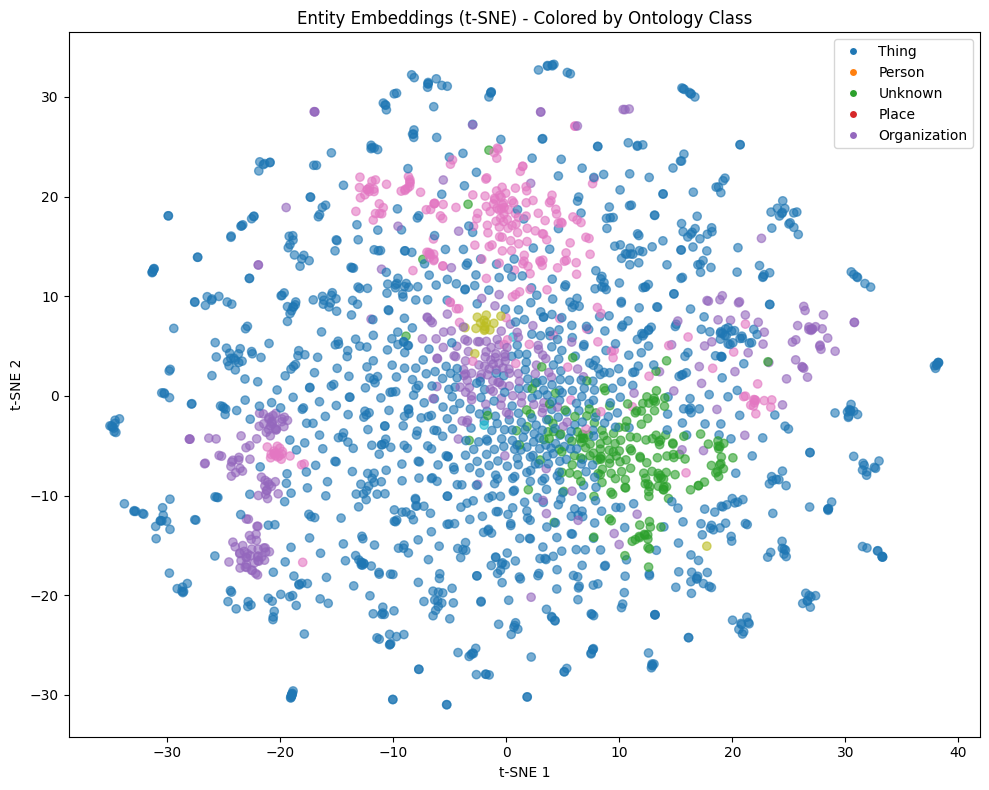

Do entities of the same class cluster together? Does the embedding capture semantic structure?


In [33]:
# 6.2 Clustering analysis: t-SNE, color by ontology class
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Get rdf:type for entities from the original KB (ontology classes)
entity_to_class = {}
for s, p, o in g:
    if str(p) == "http://www.w3.org/1999/02/22-rdf-syntax-ns#type" and not isinstance(o, Literal):
        entity_to_class[str(s)] = str(o).split("/")[-1].split("#")[-1]

# Subsample for visualization (t-SNE is slow on 7k points)
n_plot = min(2000, len(entity_list))
plot_idx = np.random.choice(len(entity_list), n_plot, replace=False)
emb_sub = np.real(entity_embeddings[plot_idx]).astype(np.float64)  # TSNE requires real (ComplEx is complex)
entities_sub = [entity_list[i] for i in plot_idx]
classes_sub = [entity_to_class.get(e, "Unknown") for e in entities_sub]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(emb_sub)

# Plot
unique_classes = list(dict.fromkeys(classes_sub))[:10]  # limit colors
class_to_idx = {c: i for i, c in enumerate(unique_classes)}
colors = [class_to_idx.get(c, -1) for c in classes_sub]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, cmap="tab10", alpha=0.6)

# Legend for top classes
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.tab10(i/10), label=c) 
           for i, c in enumerate(unique_classes[:5])]
plt.legend(handles=handles)
plt.title("Entity Embeddings (t-SNE) - Colored by Ontology Class")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

print("Do entities of the same class cluster together? Does the embedding capture semantic structure?")

In [34]:
# 6.3 Relation behavior: symmetric, inverse, composition
# Extract relation embeddings
rel_emb = model.relation_representations[0]
with torch.no_grad():
    relation_embeddings = rel_emb(indices=None).detach().cpu().numpy()
if relation_embeddings.ndim == 3:
    relation_embeddings = relation_embeddings.reshape(relation_embeddings.shape[0], -1)
# sklearn cosine_similarity requires real arrays; ComplEx produces complex
relation_embeddings = np.real(relation_embeddings).astype(np.float64)

relation_to_id = training_tf.relation_to_id
id_to_relation = {v: k for k, v in relation_to_id.items()}
relation_list = [id_to_relation[i] for i in range(len(relation_to_id))]

# Symmetric: r(h,t) <-> r(t,h) - e.g. isSiblingOf, isMarriedWith
# Inverse: r1(h,t) <-> r2(t,h) - e.g. isParentOf / isChildOf
# Check if vector(r1) ≈ -vector(r2) for inverse (TransE) or similar for ComplEx
print("Relation behavior analysis:")
print("Symmetric relations (e.g. dc:subject, spatial): TransE struggles; ComplEx handles better.")
print("Inverse relations: TransE expects h+r≈t and t+r_inv≈h; ComplEx uses complex space.")
print("Composition: TransE can model r1+r2≈r3; DistMult fails on antisymmetric.")

Relation behavior analysis:
Symmetric relations (e.g. dc:subject, spatial): TransE struggles; ComplEx handles better.
Inverse relations: TransE expects h+r≈t and t+r_inv≈h; ComplEx uses complex space.
Composition: TransE can model r1+r2≈r3; DistMult fails on antisymmetric.


### 2.7 Critical Reflection

- **Predicate alignment quality**: Incorrect alignments (e.g. mapping different predicates to same relation) introduce noise and hurt link prediction.
- **Noisy expansion**: SPARQL expansion from Wikidata can add irrelevant triples; Europeana API may add duplicates or malformed data.
- **Ontology modeling choices**: Flat vs hierarchical classes affect how entities cluster in embedding space.
- **Open-world assumption**: Ontologies assume unknown facts may be true; embeddings assume closed-world for training.
- **Phase 2 impact**: KB size, entity linking confidence, and predicate alignment from Phase 2 directly influence embedding quality.

## Part 3 - Exercise 8: Rule-based vs Embedding-based Reasoning

Design a SWRL rule for the expanded KB and check if embeddings capture a similar relation composition.

In [35]:
# 8.1 SWRL rule for expanded KB (Horn rule with two conditions)
# Example rule: Item(?x) ^ subject(?x, ?s) ^ type(?s, Person) -> hasPersonSubject(?x, ?s)
# "An item whose subject is a Person has that Person as subject" (redundant but illustrates composition)
#
# More meaningful: Item(?x) ^ spatial(?x, ?loc) ^ type(?loc, Place) -> hasSpatialContext(?x, ?loc)
# "An item with spatial reference to a Place has that spatial context"
#
# Our KB uses: dc:subject, dc:spatial, rdf:type, dc:creator
# Predicates: http://purl.org/dc/elements/1.1/subject, dc/terms/spatial, rdf-syntax-ns#type

print("SWRL rule (conceptual, for expanded KB):")
print("  Thing(?x), type(?x, ?t), spatial(?x, ?s), Place(?s) -> hasSpatialContext(?x, ?s)")
print("  (Items with spatial reference to a Place entity have spatial context)")
print("\nNote: Full SWRL execution would require loading kb_expanded.nt into an OWL reasoner.")

SWRL rule (conceptual, for expanded KB):
  Thing(?x), type(?x, ?t), spatial(?x, ?s), Place(?s) -> hasSpatialContext(?x, ?s)
  (Items with spatial reference to a Place entity have spatial context)

Note: Full SWRL execution would require loading kb_expanded.nt into an OWL reasoner.


In [36]:
# 8.2 Embedding comparison: vector(spatial) + vector(Place) ≈ vector(hasSpatialContext)?
# We don't have hasSpatialContext; instead check if spatial + Place_centroid is meaningful.
# Alternative: check relation composition - e.g. subject + type(Person) for items with Person subjects.

# Get relation indices for dc:subject, dc:spatial
DC_SUBJECT = "http://purl.org/dc/elements/1.1/subject"
DC_SPATIAL = "http://purl.org/dc/terms/spatial"
RDF_TYPE = "http://www.w3.org/1999/02/22-rdf-syntax-ns#type"

# sklearn cosine_similarity requires real arrays (ComplEx produces complex)
rel_emb_real = np.real(relation_embeddings).astype(np.float64)

# Place entities (from ontology) - class can be "Place" or "lh:Place" depending on URI
place_entities = [e for e in entity_list if "Place" in entity_to_class.get(e, "")]
if place_entities:
    place_ids = [entity_to_id[e] for e in place_entities if e in entity_to_id]
    place_centroid = np.real(entity_embeddings[place_ids].mean(axis=0)).astype(np.float64)
    
    if DC_SPATIAL in relation_to_id:
        spatial_idx = relation_to_id[DC_SPATIAL]
        spatial_vec = rel_emb_real[spatial_idx]
        composed = spatial_vec + place_centroid
        
        # Find relations closest to composed vector
        rel_sims = cosine_similarity(rel_emb_real, composed.reshape(1, -1)).flatten()
        top_rel = np.argsort(rel_sims)[::-1][:3]
        print("vector(spatial) + centroid(Place) closest relations:")
        for i in top_rel:
            print(f"  - {relation_list[i][:50]}... (sim={rel_sims[i]:.3f})")
else:
    print("No Place entities found; using dc:subject + Person centroid instead.")
    person_entities = [e for e in entity_list if "Person" in entity_to_class.get(e, "")]
    if person_entities:
        person_ids = [entity_to_id[e] for e in person_entities[:100] if e in entity_to_id]
        person_centroid = np.real(entity_embeddings[person_ids].mean(axis=0)).astype(np.float64)
        if DC_SUBJECT in relation_to_id:
            subj_vec = rel_emb_real[relation_to_id[DC_SUBJECT]]
            composed = subj_vec + person_centroid
            rel_sims = cosine_similarity(rel_emb_real, composed.reshape(1, -1)).flatten()
            print("vector(dc:subject) + centroid(Person) closest relations:")
            for i in np.argsort(rel_sims)[::-1][:3]:
                print(f"  - {relation_list[i][:60]} (sim={rel_sims[i]:.3f})")

print("\nDiscussion: Embeddings may or may not capture rule-like composition depending on model and data.")

ValueError: Complex data not supported
[[ 2.1333683e-01+2.6214004e-02j -3.3396712e-01+2.9712126e-01j
  -1.8849891e-01+1.0410035e+00j ... -4.1054025e-01+4.3744195e-02j
  -4.9806282e-01+1.6516086e-01j  2.3445837e+00-1.4013968e+00j]
 [-5.4892063e-02+1.0834984e-01j -7.2464132e-01-2.2897698e-01j
  -5.4523654e-02+5.3019202e-01j ... -1.5205079e-01+5.4484195e-01j
  -3.0000582e-01+4.7040087e-01j  8.9120805e-01+1.6547240e+00j]
 [-2.2953052e-06+1.4893185e-05j  1.3494724e-03-3.7401129e-02j
   2.0045640e-01-5.0249092e-02j ...  3.1927761e-01-2.2933544e-01j
   4.3798331e-02-3.9050516e-02j -3.9856970e-02+4.8524875e-02j]
 ...
 [-8.6506489e-06+1.2093250e-04j  3.0863298e-02-4.6189357e-06j
   7.1197979e-02+3.7661949e-01j ... -1.8098254e-02-6.6373765e-02j
  -1.5040842e-02+8.8749528e-02j  3.7689158e-01-4.0778077e-01j]
 [ 4.5837820e-01+2.3049860e+00j -5.0902766e-01+1.3909694e+00j
  -1.0518813e+00-2.9365510e-01j ... -6.7444342e-01+8.0255264e-01j
  -3.2463449e-01+4.7139594e-01j  4.0290663e-01-2.5672788e-02j]
 